In [3]:
#  importar bibliotecas
%pip install numpy pandas matplotlib seaborn scikit-learn
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split, KFold, GridSearchCV
from sklearn.ensemble import RandomForestClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 16.7/16.7 MB 25.4 MB/s  0:00:00m0:00:010:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 10.9/10.9 MB 50.1 MB/s  0:00:006m0:00:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 10.0/10.0 MB 39.9 MB/s  0:00:006m0:00:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 9.1/9.1 MB 50.3 MB/s  0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 5.0/5.0 MB 43.4 MB/s  0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.5/1.5 MB 19.6 MB/s  0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 6.9/6.9 MB 36.0 MB/s  0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 35.3/35.3 MB 48.6 MB/s  0:00:006m0:00:01
   ━━━━━━━━╺━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━  3/15 [numpy]]  WARNING: The scripts f2py and numpy-config are installed in '/usr/local/python/3.12.1/bin' which is not on PATH.
  Consider adding this directory to PATH or, if you prefer to suppress this warning, use --no-warn-script-location.
   ━━━━━━━━━━━━━━━━━━╸━━━━━━━━━━━━━━━━━━━━━  7/15 [fonttools]  WARNING: 

Revision de los datos 

In [4]:
datos = pd.read_csv("data_fraude_canastas.csv")

print(f"Filas: {datos.shape[0]:,}")
print(f"Columnas: {datos.shape[1]:,}")
datos.head()

Filas: 9,319
Columnas: 2,457


,ID,APPLE PRODUCTDESCRIPTION | SAMSUNG | MODEL90,AUDIO ACCESSORIES | AB AUDIO | AB AUDIO GO AIR TRUE WIRELESS BLUETOOTH IN-EAR H,AUDIO ACCESSORIES | APPLE | 2019 APPLE AIRPODS WITH CHARGING CASE,AUDIO ACCESSORIES | APPLE | 2019 APPLE AIRPODS WITH CHARGING CASE 2ND GENERATI,AUDIO ACCESSORIES | APPLE | 2019 APPLE AIRPODS WITH WIRELESS CHARGING CASE,AUDIO ACCESSORIES | APPLE | 2019 APPLE AIRPODS WITH WIRELESS CHARGING CASE 2ND,AUDIO ACCESSORIES | APPLE | 2021 APPLE AIRPODS WITH MAGSAFE CHARGING CASE 3RD,AUDIO ACCESSORIES | APPLE | AIRPODS PRO,AUDIO ACCESSORIES | APPLE | APPLE AIRPODS MAX,...,WOMEN S NIGHTWEAR | ANYDAY RETAILER | ANYDAY RETAILER LEOPARD PRINT JERSEY PY,WOMEN S NIGHTWEAR | RETAILER | RETAILER CLEO VELOUR JOGGER LOUNGE PANT,WOMEN S NIGHTWEAR | SOSANDAR | SOSANDAR ZEBRA PRINT PYJAMA BOTTOMS BLACK 10,Nb_of_items,total_of_items,costo_total,costo_medio_item,costo_item_max,costo_item_min,fraud_flag
0,130,0,0,0,0,0,0,0,0,0,...,0,0,0,2,2,1299,649.500000,1299,0,1
1,195,0,0,0,0,0,0,0,0,0,...,0,0,0,3,3,4119,1373.000000,2470,0,1
2,217,0,0,0,0,0,0,0,0,0,...,0,0,0,2,2,2806,1403.000000,2799,7,1
3,552,0,0,0,0,0,0,0,0,0,...,0,0,0,2,2,1206,603.000000,1199,7,1
4,854,0,0,0,0,0,0,0,0,0,...,0,0,0,19,27,1807,66.925926,195,4,1


In [5]:
columnas_resumen = [
    "Nb_of_items",
    "total_of_items",
    "costo_total",
    "costo_medio_item",
    "costo_item_max",
    "costo_item_min"
]

columnas_especiales = ["ID"] + columnas_resumen + ["fraud_flag"]
columnas_productos = [c for c in datos.columns if c not in columnas_especiales]

print(f"Columnas de productos: {len(columnas_productos):,}")
print(f"Variables resumen: {len(columnas_resumen)}")

Columnas de productos: 2,449
Variables resumen: 6


In [6]:
calidad = pd.DataFrame({
    "Métrica": [
        "Filas",
        "Columnas",
        "Valores faltantes",
        "Filas duplicadas",
        "IDs duplicados"
    ],
    "Resultado": [
        datos.shape[0],
        datos.shape[1],
        datos.isna().sum().sum(),
        datos.duplicated().sum(),
        datos["ID"].duplicated().sum()
    ]
})

calidad

,Métrica,Resultado
0,Filas,9319
1,Columnas,2457
2,Valores faltantes,0
3,Filas duplicadas,0
4,IDs duplicados,0


In [8]:
# Verificación explícita de la variable objetivo.
# Esta línea evita continuar si, por error de ejecución, fraud_flag contiene NaN.
print("NaN en fraud_flag:", datos["fraud_flag"].isna().sum())
assert datos["fraud_flag"].notna().all(), "fraud_flag contiene valores faltantes"

conteo_objetivo = datos["fraud_flag"].value_counts().sort_index()
porcentaje_objetivo = datos["fraud_flag"].value_counts(normalize=True).sort_index() * 100

resumen_objetivo = pd.DataFrame({
    "Cantidad": conteo_objetivo,
    "Porcentaje": porcentaje_objetivo
})
resumen_objetivo.index = ["No fraude (0)", "Fraude (1)"]
resumen_objetivo

NaN en fraud_flag: 0


,Cantidad,Porcentaje
No fraude (0),8000,85.846121
Fraude (1),1319,14.153879


La variable objetivo está desbalanceada: los casos de fraude son minoritarios. Por esta razón, además de la exactitud, se revisan la matriz de confusión y métricas enfocadas en la clase fraude.

In [9]:
medianas_por_clase = datos.groupby("fraud_flag")[columnas_resumen].median().T
medianas_por_clase.columns = ["No fraude", "Fraude"]
medianas_por_clase

,No fraude,Fraude
Nb_of_items,1.0,2.0
total_of_items,1.0,2.0
costo_total,1099.0,1379.0
costo_medio_item,699.0,949.0
costo_item_max,996.5,1249.0
costo_item_min,379.0,549.0


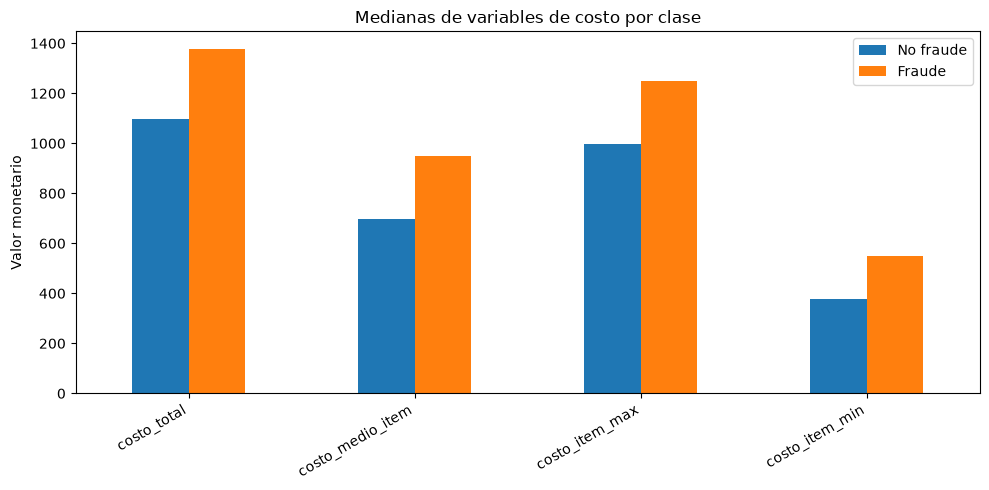

In [10]:
variables_costo = ["costo_total", "costo_medio_item", "costo_item_max", "costo_item_min"]
medianas_costos = medianas_por_clase.loc[variables_costo]

ax = medianas_costos.plot(kind="bar", figsize=(10, 5))
ax.set_title("Medianas de variables de costo por clase")
ax.set_ylabel("Valor monetario")
ax.set_xlabel("")
plt.xticks(rotation=30, ha="right")
plt.tight_layout()
plt.show()

##  División 80% entrenamiento / 20% prueba

In [11]:
columnas_modelo = columnas_productos + columnas_resumen

X = datos[columnas_modelo].copy()
y = datos["fraud_flag"].astype(int).copy()

# Comprobación antes de dividir los datos
assert y.notna().all(), "La variable objetivo contiene NaN"

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    shuffle=True,
    stratify=y,
    random_state=8
)

print(f"Entrenamiento: {X_train.shape[0]:,} filas")
print(f"Prueba:        {X_test.shape[0]:,} filas")
print(f"Fraude en train: {y_train.mean():.2%}")
print(f"Fraude en test:  {y_test.mean():.2%}")

Entrenamiento: 7,455 filas
Prueba:        1,864 filas
Fraude en train: 14.15%
Fraude en test:  14.16%


#  Random Forest

In [12]:
# Modelo Random Forest 
modelo_rf = RandomForestClassifier(
    n_estimators=1000,
    random_state=0,
    criterion="entropy",
    n_jobs=-1  # Solo acelera el cálculo; no cambia el modelo
)

modelo_rf.fit(X_train, y_train)

pred_train_rf = modelo_rf.predict(X_train)
pred_test_rf = modelo_rf.predict(X_test)

print(
    "Exactitud del Random Forest en entrenamiento: {:4.2f}%"
    .format(accuracy_score(y_train, pred_train_rf) * 100)
)

print(
    "Exactitud del Random Forest en prueba: {:4.2f}%"
    .format(accuracy_score(y_test, pred_test_rf) * 100)
)

Exactitud del Random Forest en entrenamiento: 92.39%
Exactitud del Random Forest en prueba: 88.57%


Umbral de clasificacion , se toma el 0.10 , para priorizar fraudes reales, pero con riesgo de aumentar falsas alarmas

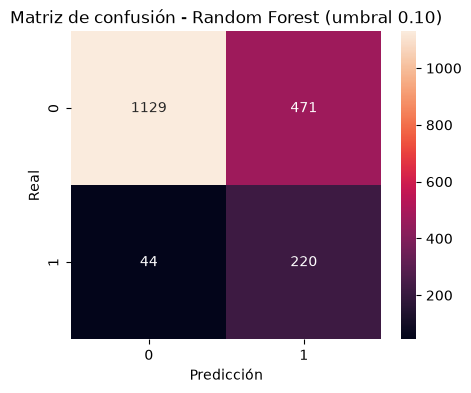

,Random Forest
Accuracy,0.723712
Precision,0.318379
Recall,0.833333
F1,0.460733


In [13]:
umbral = 0.10

prob_test_rf = modelo_rf.predict_proba(X_test)[:, 1]
pred_umbral_rf = np.where(prob_test_rf > umbral, 1, 0)

matriz_rf = pd.crosstab(
    y_test,
    pred_umbral_rf,
    rownames=["Real"],
    colnames=["Predicción"]
)

plt.figure(figsize=(5, 4))
sns.heatmap(matriz_rf, annot=True, fmt="g")
plt.title(f"Matriz de confusión - Random Forest (umbral {umbral:.2f})")
plt.show()

metricas_rf = pd.Series({
    "Accuracy": accuracy_score(y_test, pred_umbral_rf),
    "Precision": precision_score(y_test, pred_umbral_rf, zero_division=0),
    "Recall": recall_score(y_test, pred_umbral_rf),
    "F1": f1_score(y_test, pred_umbral_rf)
}, name="Random Forest")

metricas_rf.to_frame()

#  Regresión logística sin penalización

In [14]:
# Modelo base siguiendo la estructura del notebook de regresión logística
modelo_lr = LogisticRegression(
    penalty=None,
    random_state=4,
    max_iter=100,
    tol=0.001,
    solver="sag"
)

modelo_lr.fit(X_train, y_train)

pred_train_lr = modelo_lr.predict(X_train)
pred_test_lr = modelo_lr.predict(X_test)

print(
    "Exactitud de la Regresión Logística en entrenamiento: {:4.2f}%"
    .format(accuracy_score(y_train, pred_train_lr) * 100)
)

print(
    "Exactitud de la Regresión Logística en prueba: {:4.2f}%"
    .format(accuracy_score(y_test, pred_test_lr) * 100)
)

/usr/local/python/3.12.1/lib/python3.12/site-packages/sklearn/linear_model/_logistic.py:1403: FutureWarning: 'penalty' was deprecated in version 1.8 and will be removed in 1.10. To avoid this warning, leave 'penalty' set to its default value and use 'l1_ratio' or 'C' instead. Use l1_ratio=0 instead of penalty='l2', l1_ratio=1 instead of penalty='l1', l1_ratio set to a float between 0 and 1 instead of penalty='elasticnet', and C=np.inf instead of penalty=None.
  warnings.warn(


Exactitud de la Regresión Logística en entrenamiento: 86.81%
Exactitud de la Regresión Logística en prueba: 86.32%


/usr/local/python/3.12.1/lib/python3.12/site-packages/sklearn/linear_model/_sag.py:348: ConvergenceWarning: The max_iter was reached which means the coef_ did not converge
  warnings.warn(


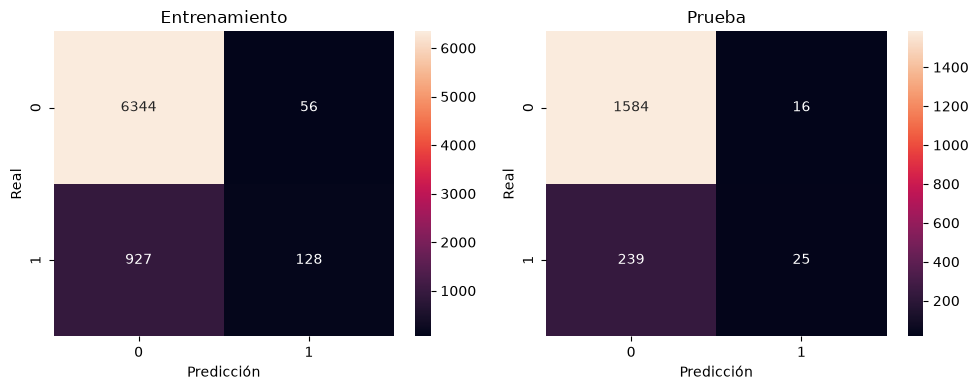

In [15]:
matriz_train_lr = pd.crosstab(
    y_train,
    pred_train_lr,
    rownames=["Real"],
    colnames=["Predicción"]
)

matriz_test_lr = pd.crosstab(
    y_test,
    pred_test_lr,
    rownames=["Real"],
    colnames=["Predicción"]
)

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(10, 4))

sns.heatmap(matriz_train_lr, annot=True, fmt="g", ax=ax1)
ax1.set_title("Entrenamiento")

sns.heatmap(matriz_test_lr, annot=True, fmt="g", ax=ax2)
ax2.set_title("Prueba")

plt.tight_layout()
plt.show()

In [16]:
# Modelo final Ridge con el mejor C encontrado
C_best = 0.1

modelo_ridge = LogisticRegression(
    penalty="l2",
    C=C_best,
    solver="sag",
    max_iter=100,
    tol=0.001,
    warm_start=True,
    random_state=4
)

modelo_ridge.fit(X_train, y_train)

pred_train_ridge = modelo_ridge.predict(X_train)
pred_test_ridge = modelo_ridge.predict(X_test)

print(
    "Exactitud Ridge en entrenamiento: {:4.2f}%"
    .format(accuracy_score(y_train, pred_train_ridge) * 100)
)

print(
    "Exactitud Ridge en prueba: {:4.2f}%"
    .format(accuracy_score(y_test, pred_test_ridge) * 100)
)

/usr/local/python/3.12.1/lib/python3.12/site-packages/sklearn/linear_model/_logistic.py:1403: FutureWarning: 'penalty' was deprecated in version 1.8 and will be removed in 1.10. To avoid this warning, leave 'penalty' set to its default value and use 'l1_ratio' or 'C' instead. Use l1_ratio=0 instead of penalty='l2', l1_ratio=1 instead of penalty='l1', l1_ratio set to a float between 0 and 1 instead of penalty='elasticnet', and C=np.inf instead of penalty=None.
  warnings.warn(


Exactitud Ridge en entrenamiento: 86.81%
Exactitud Ridge en prueba: 86.32%


/usr/local/python/3.12.1/lib/python3.12/site-packages/sklearn/linear_model/_sag.py:348: ConvergenceWarning: The max_iter was reached which means the coef_ did not converge
  warnings.warn(


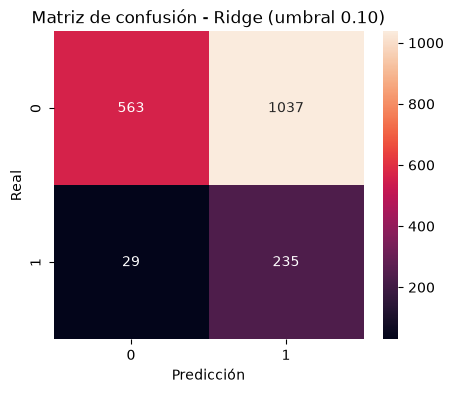

,Logística Ridge
Accuracy,0.428112
Precision,0.184748
Recall,0.890152
F1,0.305990


In [17]:
prob_test_ridge = modelo_ridge.predict_proba(X_test)[:, 1]
pred_umbral_ridge = np.where(prob_test_ridge > umbral, 1, 0)

matriz_ridge = pd.crosstab(
    y_test,
    pred_umbral_ridge,
    rownames=["Real"],
    colnames=["Predicción"]
)

plt.figure(figsize=(5, 4))
sns.heatmap(matriz_ridge, annot=True, fmt="g")
plt.title(f"Matriz de confusión - Ridge (umbral {umbral:.2f})")
plt.show()

metricas_ridge = pd.Series({
    "Accuracy": accuracy_score(y_test, pred_umbral_ridge),
    "Precision": precision_score(y_test, pred_umbral_ridge, zero_division=0),
    "Recall": recall_score(y_test, pred_umbral_ridge),
    "F1": f1_score(y_test, pred_umbral_ridge)
}, name="Logística Ridge")

metricas_ridge.to_frame()

# Comparación final de los modelos

In [18]:
comparacion_modelos = pd.concat(
    [metricas_rf, metricas_ridge],
    axis=1
).T

comparacion_modelos

,Accuracy,Precision,Recall,F1
Random Forest,0.723712,0.318379,0.833333,0.460733
Logística Ridge,0.428112,0.184748,0.890152,0.305990


# Conclusion: 

La comparación final muestra que la Regresión Logística Ridge obtiene el mayor recall (89.0%), por lo que detecta una mayor proporción de los fraudes reales. Sin embargo, su baja precisión (18.5%) indica que genera una cantidad elevada de falsos positivos. El Random Forest presenta un mejor balance general, con un recall de 83.3%, una precisión de 31.8% y el mayor F1 (46.1%). Por esta razón, se selecciona Random Forest como el modelo final.